# FSA Prediction Model

This notebook runs the cleaned FSA-level prediction model.

Workflow:
- change the settings below
- run the model for all FSAs
- inspect one selected FSA
- the full yearly outputs for every FSA are saved automatically under `outputs/fsa/`

Use `TARGET_FSA` to inspect a different postal area and `FORECAST_END_YEAR` if you want a different horizon.

In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_DIR = Path(__file__).resolve().parents[1]
SRC_DIR = PROJECT_DIR / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from prediction_model import ModelConfig, OUTPUT_DIR, VEHICLE_TYPES, run_fsa_model, save_fsa_outputs

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


## Settings

Update these values and rerun the notebook when you want another FSA or another forecast horizon.

In [2]:
FORECAST_END_YEAR = 2035
SELECTED_YEAR = 2035
TARGET_FSA = "H3A"

config = ModelConfig(
    forecast_end_year=FORECAST_END_YEAR,
    selected_year=SELECTED_YEAR,
)


In [3]:
fsa_result = run_fsa_model(config)
fsa_output_dir = save_fsa_outputs(fsa_result, OUTPUT_DIR / "fsa")
fsa_output_dir


PosixPath('/Users/natomanzolli/Documents/GitHub/MATSim-agent-vehicle-assignment/adoption prediction model/outputs/fsa')

## Selected Year Summary Across All FSAs

In [4]:
fsa_result["summary_year"].sort_values(f"total_vehicles_{config.selected_year}", ascending=False).head(15)


vehicle_type,fsa,fleet_share_electric,fleet_share_hev_sedan,fleet_share_hev_suv,fleet_share_ice_sedan,fleet_share_ice_suv,fleet_share_ice_van/pickup,sales_share_electric,sales_share_hev_sedan,sales_share_hev_suv,sales_share_ice_sedan,sales_share_ice_suv,sales_share_ice_van/pickup,total_vehicles_2035
342,J0K,0.114434,0.034129,0.042444,0.108764,0.538330,0.161899,0.146024,0.032259,0.054817,0.0,0.542046,0.224854,115214.385727
343,J0L,0.147775,0.038698,0.045445,0.070544,0.574806,0.122732,0.166878,0.034693,0.053105,0.0,0.553434,0.191890,67423.255813
12,G0R,0.054083,0.022346,0.041840,0.107661,0.617272,0.156798,0.071411,0.023573,0.054458,0.0,0.639205,0.211353,66385.278445
0,G0A,0.105661,0.020735,0.063276,0.018596,0.649187,0.142545,0.107466,0.018258,0.064992,0.0,0.616203,0.193081,64748.517186
13,G0S,0.057087,0.012359,0.042777,0.120482,0.621739,0.145556,0.076167,0.012706,0.057904,0.0,0.637632,0.215590,55409.318470
336,J0B,0.107608,0.040586,0.061004,0.117257,0.550429,0.123116,0.137362,0.040356,0.080753,0.0,0.547147,0.194383,50998.457635
486,J7V,0.127800,0.036527,0.064276,0.084524,0.624636,0.062236,0.141546,0.031310,0.071641,0.0,0.665297,0.090207,48530.439706
17,G0X,0.095163,0.037056,0.052805,0.117540,0.503300,0.194137,0.132309,0.040543,0.074741,0.0,0.497924,0.254483,48439.652909
8,G0L,0.070620,0.025583,0.053175,0.087269,0.617416,0.145937,0.087914,0.024829,0.066790,0.0,0.616856,0.203611,46945.975053
411,J3Y,0.116431,0.043973,0.069075,0.107115,0.612011,0.051395,0.136089,0.042814,0.079567,0.0,0.656198,0.085332,43666.405548


## Selected FSA: Sales Share by Year

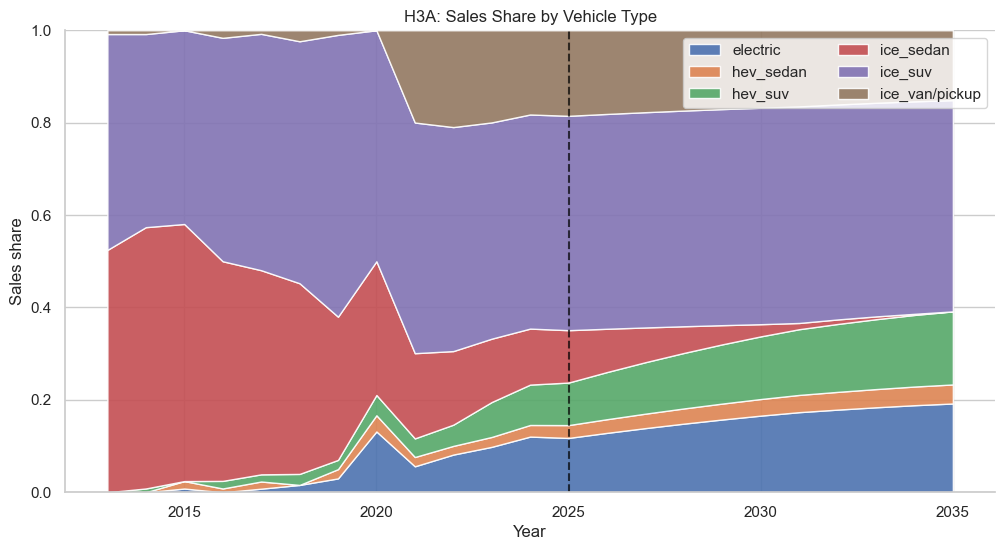

In [5]:
selected_sales = fsa_result["fsa_sales_share_by_year"].query("fsa == @TARGET_FSA").set_index("year")
fig, ax = plt.subplots(figsize=(12, 6))
ax.stackplot(selected_sales.index, [selected_sales[col] for col in VEHICLE_TYPES], labels=VEHICLE_TYPES, alpha=0.9)
ax.axvline(config.observed_share_end_year, color="black", linestyle="--", alpha=0.7)
ax.set_title(f"{TARGET_FSA}: Sales Share by Vehicle Type")
ax.set_xlabel("Year")
ax.set_ylabel("Sales share")
ax.set_ylim(0, 1)
ax.legend(ncol=2, loc="upper right")
plt.show()


## Selected FSA: Fleet Market Share by Year

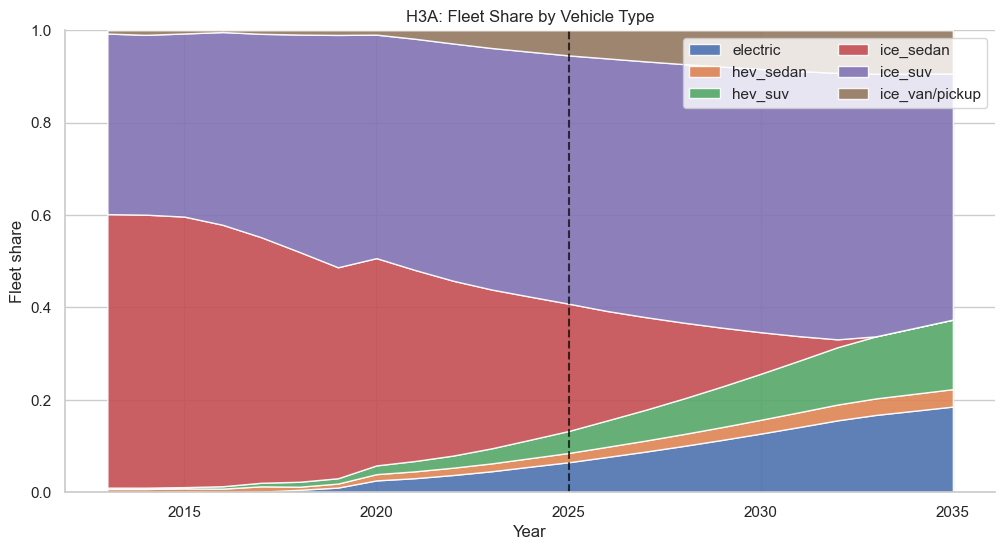

In [8]:
selected_fleet = fsa_result["fsa_fleet_share_by_year"].query("fsa == @TARGET_FSA").set_index("year")
fig, ax = plt.subplots(figsize=(12, 6))
ax.stackplot(selected_fleet.index, [selected_fleet[col] for col in VEHICLE_TYPES], labels=VEHICLE_TYPES, alpha=0.9)
ax.axvline(config.observed_share_end_year, color="black", linestyle="--", alpha=0.7)
ax.set_title(f"{TARGET_FSA}: Fleet Share by Vehicle Type")
ax.set_xlabel("Year")
ax.set_ylabel("Fleet share")
ax.set_ylim(0, 1)
ax.legend(ncol=2, loc="upper right")
plt.show()


## Selected FSA: Total Vehicle Count

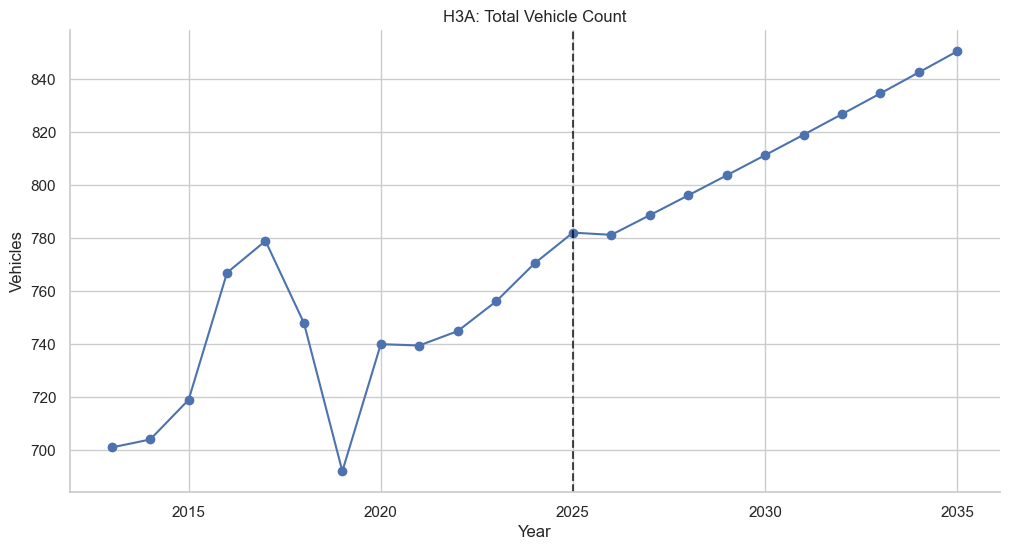

In [7]:
selected_counts = fsa_result["fsa_vehicle_counts_by_year"].query("fsa == @TARGET_FSA").set_index("year")
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(selected_counts.index, selected_counts["total_vehicles"], marker="o")
ax.axvline(config.observed_share_end_year, color="black", linestyle="--", alpha=0.7)
ax.set_title(f"{TARGET_FSA}: Total Vehicle Count")
ax.set_xlabel("Year")
ax.set_ylabel("Vehicles")
plt.show()


## Output Files

In [ ]:
sorted(path.name for path in fsa_output_dir.iterdir())